# **Proyecto final: Telecomunicaciones — identificación de operadores ineficaces**

**Enlace al proyecto en Google Drive:** 

https://drive.google.com/drive/u/1/folders/1xz4P5G6xzuLLHcAyNRHT1x6g78fFFJQB

## Objetivo
El objetivo de este proyecto es identificar operadores ineficaces para el servicio CallMeMaybe.

Un operador se considerará ineficaz si presenta una alta cantidad de llamadas entrantes perdidas, tiempos de espera prolongados en llamadas entrantes y, en los casos donde corresponda, un bajo volumen de llamadas salientes.

## Plan de trabajo
1. Cargar y explorar los datos
2. Limpiar y preparar la información
3. Realizar análisis exploratorio
4. Definir criterios de ineficacia
5. Identificar operadores ineficaces
6. Probar hipótesis estadísticas
7. Presentar conclusiones y recomendaciones

# **1. Cargar y explorar datos**

In [1]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_style('whitegrid')

In [2]:
# Carga de datos
clients = pd.read_csv('/datasets/telecom_clients_us.csv')
telecom = pd.read_csv('/datasets/telecom_dataset_us.csv')

In [3]:
# Exploración inicial

print('clients:')
display(clients.head())
print(clients.info())
print(clients.isna().sum())
print()
print('duplicados:', clients.duplicated().sum())

print('\n' + '='*60 + '\n')

print('telecom:')
display(telecom.head())
print(telecom.info())
print(telecom.isna().sum())
print()
print('duplicados:', telecom.duplicated().sum())

clients:


,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB
None
user_id        0
tariff_plan    0
date_start     0
dtype: int64

duplicados: 0


telecom:


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.00,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.00,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.00,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.00,True,3,0,25


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB
None
user_id                   0
date                      0
direction                 0
internal                117
operator_id            8172
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64



In [4]:
# Conversión de fechas

clients['date_start'] = pd.to_datetime(clients['date_start'])
telecom['date'] = pd.to_datetime(telecom['date'])

In [5]:
# Revisión básica de valores

display(clients.describe(include='all'))
display(telecom.describe(include='all'))

,user_id,tariff_plan,date_start
count,732.00,732,732
unique,NaN,3,73
top,NaN,C,2019-09-24 00:00:00
freq,NaN,395,24
first,NaN,NaN,2019-08-01 00:00:00
last,NaN,NaN,2019-10-31 00:00:00
mean,167431.93,NaN,NaN
std,633.81,NaN,NaN
min,166373.00,NaN,NaN
25%,166900.75,NaN,NaN


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
count,53902.00,53902,53902,53785,45730.00,53902,53902.00,53902.00,53902.00
unique,NaN,119,2,2,NaN,2,NaN,NaN,NaN
top,NaN,2019-11-25 00:00:00+03:00,out,False,NaN,False,NaN,NaN,NaN
freq,NaN,1220,31917,47621,NaN,30334,NaN,NaN,NaN
first,NaN,2019-08-02 00:00:00+03:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last,NaN,2019-11-28 00:00:00+03:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,167295.34,NaN,NaN,NaN,916535.99,NaN,16.45,866.68,1157.13
std,598.88,NaN,NaN,NaN,21254.12,NaN,62.92,3731.79,4403.47
min,166377.00,NaN,NaN,NaN,879896.00,NaN,1.00,0.00,0.00
25%,166782.00,NaN,NaN,NaN,900788.00,NaN,1.00,0.00,47.00


In [6]:
# Revisión de categorías clave

for col in ['direction', 'internal', 'is_missed_call']:
    print(f'\n{col}')
    print(telecom[col].value_counts(dropna=False))


direction
out    31917
in     21985
Name: direction, dtype: int64

internal
False    47621
True      6164
NaN        117
Name: internal, dtype: int64

is_missed_call
False    30334
True     23568
Name: is_missed_call, dtype: int64


## Análisis inicial de los datos

Se realizó una exploración preliminar de los datasets `clients` y `telecom` con el objetivo de comprender su estructura, calidad y posibles problemas antes de proceder con la limpieza y el análisis.

### Dataset de clientes (`clients`)

- El dataset contiene 732 registros y 3 columnas: `user_id`, `tariff_plan` y `date_start`.
- No se identificaron valores nulos en ninguna de las columnas.
- No se encontraron registros duplicados.
- La columna `tariff_plan` contiene 3 categorías distintas.
- La columna `date_start` fue convertida correctamente a tipo fecha.

**Conclusión:**  
El dataset de clientes se encuentra limpio y listo para su uso en el análisis.

---

### Dataset de telecomunicaciones (`telecom`)

- El dataset contiene 53,902 registros y 9 columnas.
- Las variables incluyen información sobre llamadas (dirección, duración, operador, etc.).

#### Problemas detectados

- **Valores nulos:**
  - `operator_id`: 8,172 valores nulos.
  - `internal`: 117 valores nulos.

- **Duplicados:**
  - Se identificaron 4,900 registros duplicados.

- **Tipos de datos:**
  - `date` estaba en formato texto y fue convertido a tipo datetime.
  - `operator_id` está en formato float, lo cual no es adecuado para un identificador.

- **Distribución de variables clave:**
  - `direction`:
    - salientes (`out`): mayor proporción
    - entrantes (`in`): menor proporción
  - `internal`:
    - mayoría de llamadas externas (`False`)
    - menor proporción de llamadas internas (`True`)
  - `is_missed_call`:
    - predominan llamadas no perdidas
    - existe una proporción significativa de llamadas perdidas

---

### Implicaciones para el análisis

Los problemas detectados pueden afectar directamente la identificación de operadores ineficaces:

- Los **duplicados** pueden distorsionar métricas como número de llamadas o duración.
- Los registros sin `operator_id` no pueden ser asociados a ningún operador, por lo que no son útiles para el análisis de desempeño.
- Los valores nulos en `internal` pueden afectar la segmentación de llamadas.

---

### Conclusión

Antes de continuar con el análisis, es necesario realizar un proceso de limpieza de datos que incluya:

- Eliminación de duplicados
- Eliminación de registros sin operador
- Tratamiento de valores nulos
- Ajuste de tipos de datos

Esto permitirá garantizar la calidad y confiabilidad de los resultados en las siguientes etapas del proyecto.

# **2. Limpiar y preparar la información**

In [7]:
# Eliminar duplicados
telecom = telecom.drop_duplicates()
print('Duplicados después:', telecom.duplicated().sum())

Duplicados después: 0


In [8]:
# Eliminar filas sin operador
telecom = telecom.dropna(subset=['operator_id'])

In [9]:
# Limpiar columna internal
telecom['internal'] = telecom['internal'].fillna(False)

In [10]:
# Convertir operador_id a entero
telecom['operator_id'] = telecom['operator_id'].astype(int)

In [11]:
# Verificación final
print(telecom.info())
print(telecom.isna().sum())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 41546 entries, 1 to 53899
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype                                
---  ------               --------------  -----                                
 0   user_id              41546 non-null  int64                                
 1   date                 41546 non-null  datetime64[ns, pytz.FixedOffset(180)]
 2   direction            41546 non-null  object                               
 3   internal             41546 non-null  bool                                 
 4   operator_id          41546 non-null  int64                                
 5   is_missed_call       41546 non-null  bool                                 
 6   calls_count          41546 non-null  int64                                
 7   call_duration        41546 non-null  int64                                
 8   total_call_duration  41546 non-null  int64                                
dtypes: bool

# **Observación:**
Se eliminaron duplicados para evitar distorsión en métricas

Se eliminaron registros sin operador ya que no son analizables

Se imputó internal como False para mantener consistencia

Se ajustó tipo de operator_id para análisis correcto

# **3. Realizar análisis exploratorio**

## Análisis exploratorio de operadores

Para comprender el desempeño de los operadores, se construyeron métricas agregadas a nivel de operador.

### Métricas a analizar

- Total de llamadas entrantes
- Número de llamadas entrantes perdidas
- Tasa de llamadas perdidas
- Tiempo promedio de espera
- Total de llamadas salientes

### Objetivo del análisis

El objetivo de esta etapa es identificar patrones de comportamiento en los operadores y entender la distribución de las métricas clave antes de definir criterios de ineficacia.

Este análisis permitirá establecer umbrales adecuados en la siguiente etapa del proyecto.

In [12]:
#Crear variables necesarias
# Tiempo de espera = tiempo total - duración de llamada
telecom['wait_time'] = telecom['total_call_duration'] - telecom['call_duration']

In [13]:
#Filtrar tipos de llamadas
# Llamadas entrantes (relevantes para eficiencia en atención)
incoming = telecom[telecom['direction'] == 'in']
# Llamadas salientes (relevantes para productividad)
outgoing = telecom[telecom['direction'] == 'out']

In [14]:
# Métricas para llamadas entrantes
incoming_metrics = incoming.groupby('operator_id').agg(
    total_in_calls=('calls_count', 'sum'), # total de llamadas recibidas
    missed_in_calls=('is_missed_call', 'sum'), # llamadas perdidas
    avg_wait_time=('wait_time', 'mean') # tiempo promedio de espera
).reset_index()

# Cálculo de tasa de llamadas perdidas
incoming_metrics['missed_rate'] = (
    incoming_metrics['missed_in_calls'] / incoming_metrics['total_in_calls']
)

In [15]:
# Métricas para llamadas salientes
outgoing_metrics = outgoing.groupby('operator_id').agg(
    total_out_calls=('calls_count', 'sum') # total de llamadas realizadas
).reset_index()

In [16]:
# Unir métricas
operator_metrics = incoming_metrics.merge(
    outgoing_metrics,
    on='operator_id',
    how='left'
)
# Reemplazar NaN por 0 en llamadas salientes
operator_metrics['total_out_calls'] = operator_metrics['total_out_calls'].fillna(0)

In [17]:
#  RESULTADO FINAL
display(operator_metrics.head())
print(operator_metrics.describe())

,operator_id,total_in_calls,missed_in_calls,avg_wait_time,missed_rate,total_out_calls
0,879896,58,0,27.33,0.00,872.00
1,879898,104,0,29.47,0.00,7209.00
2,880020,7,0,7.71,0.00,38.00
3,880022,8,0,14.00,0.00,189.00
4,880026,24,0,7.94,0.00,2208.00


       operator_id  total_in_calls  missed_in_calls  avg_wait_time  \
count       754.00          754.00           754.00         754.00   
mean     923704.40          124.41             0.91          57.61   
std       22646.73          356.45             2.41          94.46   
min      879896.00            1.00             0.00           1.00   
25%      905153.00            4.00             0.00          17.50   
50%      924580.00           17.00             0.00          31.00   
75%      940457.50           78.75             1.00          58.00   
max      973286.00         4766.00            28.00        1007.38   

       missed_rate  total_out_calls  
count       754.00           754.00  
mean          0.01           456.76  
std           0.06          3148.99  
min           0.00             0.00  
25%           0.00             0.00  
50%           0.00            23.00  
75%           0.01           229.50  
max           1.00         58977.00  


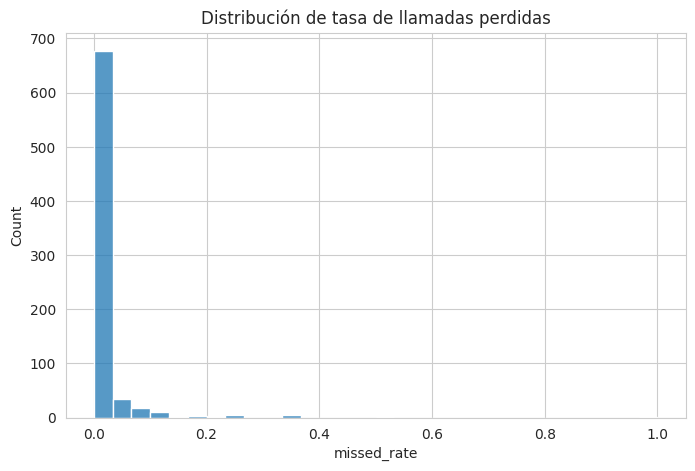

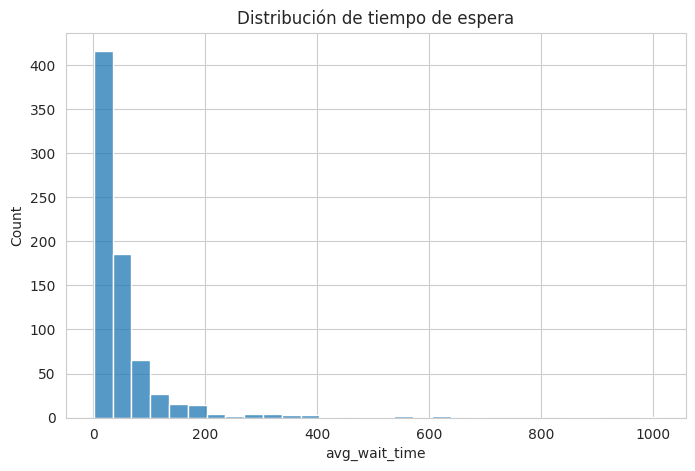

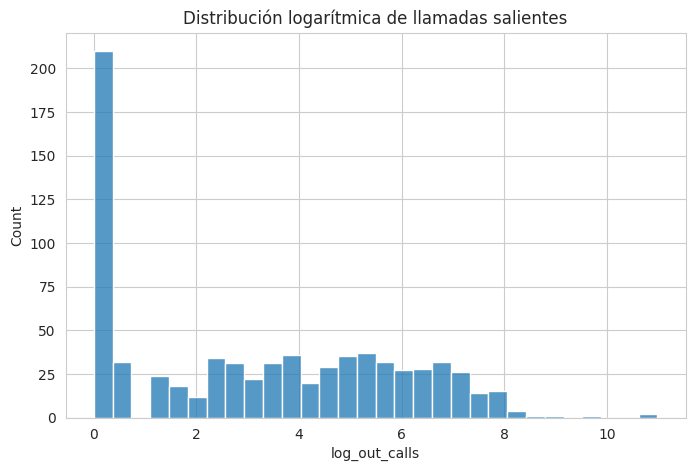

In [18]:
# =========================================
# Distribución de tasa de llamadas perdidas
# =========================================

plt.figure(figsize=(8,5))
sns.histplot(operator_metrics['missed_rate'], bins=30)
plt.title('Distribución de tasa de llamadas perdidas')
plt.show()


# =========================================
# Distribución de tiempo de espera
# =========================================

plt.figure(figsize=(8,5))
sns.histplot(operator_metrics['avg_wait_time'], bins=30)
plt.title('Distribución de tiempo de espera')
plt.show()


# =========================================
# Distribución de llamadas salientes (LOG)
# =========================================

# Usamos log1p para evitar problemas con valores en 0
operator_metrics['log_out_calls'] = np.log1p(operator_metrics['total_out_calls'])

plt.figure(figsize=(8,5))
sns.histplot(operator_metrics['log_out_calls'], bins=30)
plt.title('Distribución logarítmica de llamadas salientes')
plt.show()


## Hallazgos del análisis exploratorio

- La mayoría de los operadores presentan tasas muy bajas de llamadas perdidas, lo que indica un desempeño general adecuado en la atención de llamadas entrantes. Sin embargo, existen operadores con tasas significativamente más altas, lo que sugiere posibles problemas de desempeño.

- El tiempo de espera muestra una alta variabilidad, con presencia de valores extremos. Esto indica que algunos operadores generan tiempos de espera considerablemente mayores, lo que puede impactar negativamente la experiencia del cliente.

- El volumen de llamadas salientes presenta una distribución altamente sesgada, donde pocos operadores concentran una gran cantidad de llamadas, mientras que la mayoría realiza pocas. Esto evidencia diferencias importantes en la productividad.

Estos hallazgos confirman la necesidad de establecer criterios objetivos para identificar operadores ineficaces en la siguiente etapa del análisis.

# **4. Definir criterios de ineficacia**

In [19]:
# =========================================
# CÁLCULO DE UMBRALES (percentiles)
# =========================================

# Percentil 75 para variables donde un valor alto refleja peor desempeño
missed_threshold = operator_metrics['missed_rate'].quantile(0.75)
wait_threshold = operator_metrics['avg_wait_time'].quantile(0.75)

# El percentil 25 de llamadas salientes se calcula solo con fines exploratorios
outgoing_threshold = operator_metrics['total_out_calls'].quantile(0.25)


# =========================================
# IDENTIFICACIÓN DE OPERADORES INEFICACES
# =========================================

# Se considera ineficaz a un operador si supera el umbral de llamadas perdidas
# o si presenta un tiempo de espera superior al percentil 75
operator_metrics['inefficient'] = (
    (operator_metrics['missed_rate'] > missed_threshold) |
    (operator_metrics['avg_wait_time'] > wait_threshold)
)


# =========================================
# RESULTADOS
# =========================================

inefficient_operators = operator_metrics[operator_metrics['inefficient']]

print("Total de operadores analizados:", len(operator_metrics))
print("Total de operadores ineficaces:", len(inefficient_operators))

display(inefficient_operators.head())

Total de operadores analizados: 754
Total de operadores ineficaces: 312


,operator_id,total_in_calls,missed_in_calls,avg_wait_time,missed_rate,total_out_calls,log_out_calls,inefficient
8,882680,99,3,37.00,0.03,0.00,0.00,True
9,882684,613,4,190.52,0.01,661.00,6.50,True
10,882686,766,5,165.75,0.01,2884.00,7.97,True
11,882688,15,0,336.50,0.00,43.00,3.78,True
12,882690,171,2,322.82,0.01,1417.00,7.26,True


In [20]:
# =========================================
# UMBRALES UTILIZADOS EN EL ANÁLISIS
# =========================================

print("Umbral de tasa de llamadas perdidas (P75):", missed_threshold)
print("Umbral de tiempo de espera promedio (P75):", wait_threshold)
print("Umbral exploratorio de llamadas salientes (P25):", outgoing_threshold)

Umbral de tasa de llamadas perdidas (P75): 0.006320279940237478
Umbral de tiempo de espera promedio (P75): 58.0
Umbral exploratorio de llamadas salientes (P25): 0.0


## Definición de criterios de ineficacia

Para identificar operadores ineficaces, se establecieron criterios basados en la distribución de las métricas obtenidas en el análisis exploratorio.

### Metodología

Se utilizaron percentiles para definir umbrales objetivos:

- Percentil 75 para identificar valores altos en variables donde un mayor valor representa peor desempeño.
- Percentil 25 para explorar valores bajos en llamadas salientes.

### Criterios definidos

Se consideró ineficaz a un operador si cumple al menos una de las siguientes condiciones:

- Presenta una tasa de llamadas perdidas superior al percentil 75.
- Presenta un tiempo promedio de espera superior al percentil 75.

### Consideración sobre llamadas salientes

También se exploró la variable de llamadas salientes como posible indicador de baja productividad. Sin embargo, el percentil 25 de esta métrica resultó ser igual a 0, lo que indica una alta concentración de operadores sin llamadas salientes registradas.

Debido a ello, esta variable no se incorporó al criterio final general de ineficacia, ya que para utilizarla correctamente sería necesario distinguir primero qué operadores tienen realmente funciones de llamadas salientes.

### Justificación

El uso de percentiles permite establecer criterios basados en el comportamiento real de los datos, evitando decisiones arbitrarias y asegurando una evaluación objetiva del desempeño de los operadores.

# **5. Identificar operadores ineficaces**

In [21]:
# =========================================
# SEPARACIÓN DE GRUPOS
# =========================================

efficient_operators = operator_metrics[~operator_metrics['inefficient']]
inefficient_operators = operator_metrics[operator_metrics['inefficient']]

In [22]:
# =========================================
# COMPARACIÓN DE PROMEDIOS
# =========================================

comparison = pd.DataFrame({
    'Grupo': ['Eficientes', 'Ineficientes'],
    'Missed Rate': [
        efficient_operators['missed_rate'].mean(),
        inefficient_operators['missed_rate'].mean()
    ],
    'Avg Wait Time': [
        efficient_operators['avg_wait_time'].mean(),
        inefficient_operators['avg_wait_time'].mean()
    ],
    'Total Out Calls': [
        efficient_operators['total_out_calls'].mean(),
        inefficient_operators['total_out_calls'].mean()
    ]
})

display(comparison)

,Grupo,Missed Rate,Avg Wait Time,Total Out Calls
0,Eficientes,0.00,24.22,187.92
1,Ineficientes,0.03,104.92,837.62


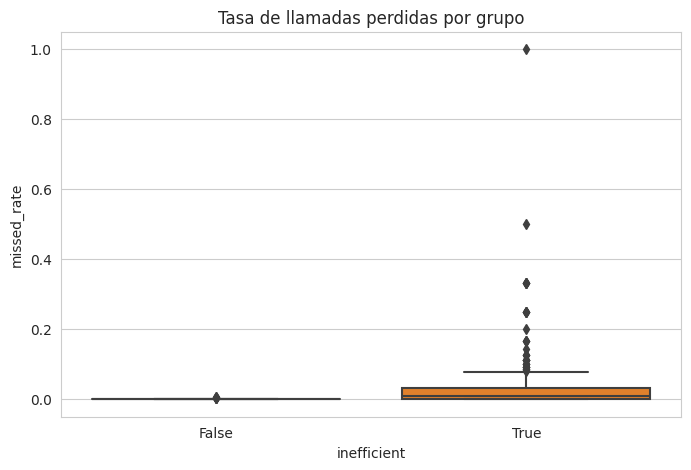

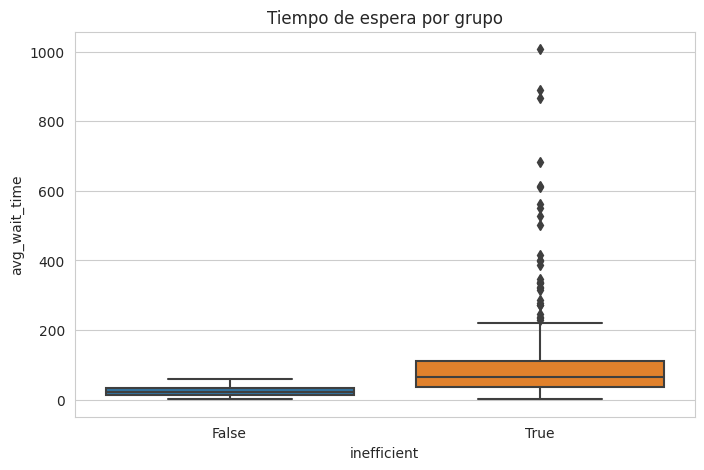

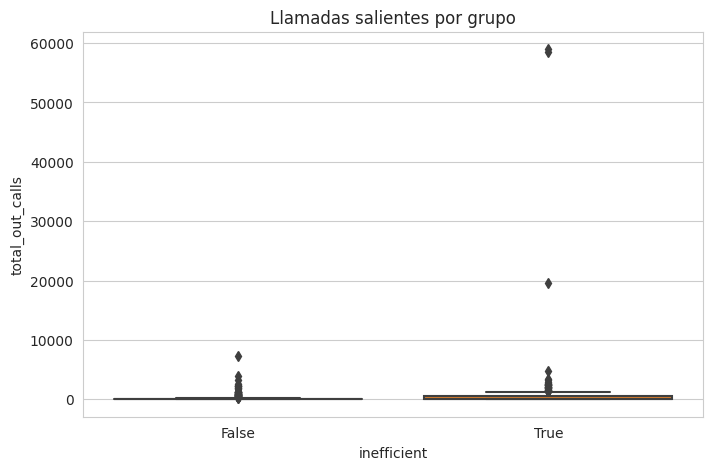

In [23]:
# =========================================
# BOXPLOTS COMPARATIVOS
# =========================================

plt.figure(figsize=(8,5))
sns.boxplot(data=operator_metrics, x='inefficient', y='missed_rate')
plt.title('Tasa de llamadas perdidas por grupo')
plt.show()


plt.figure(figsize=(8,5))
sns.boxplot(data=operator_metrics, x='inefficient', y='avg_wait_time')
plt.title('Tiempo de espera por grupo')
plt.show()


plt.figure(figsize=(8,5))
sns.boxplot(data=operator_metrics, x='inefficient', y='total_out_calls')
plt.title('Llamadas salientes por grupo')
plt.show()

## 5. Análisis de operadores ineficaces

Una vez identificados los operadores ineficaces, se realizó un análisis comparativo entre operadores eficientes e ineficientes.

### Comparación de desempeño

Se analizaron las siguientes métricas:

- Tasa de llamadas perdidas
- Tiempo promedio de espera
- Número de llamadas salientes

### Hallazgos principales

- Los operadores ineficaces presentan, en promedio, una mayor tasa de llamadas perdidas.
- También muestran tiempos de espera considerablemente más altos, lo que indica menor eficiencia en la atención.
- En cuanto a llamadas salientes, los operadores ineficaces presentan en promedio un mayor volumen; sin embargo, esta variable no se consideró determinante en la definición de ineficacia debido a la alta variabilidad y concentración de valores en cero observada en el análisis exploratorio.

### Conclusión

Los resultados confirman que la ineficacia de los operadores está principalmente asociada con problemas en la gestión de llamadas entrantes, específicamente en la atención oportuna y en la reducción de llamadas perdidas.

# **6. Probar hipótesis estadísticas**

### **Objetivo**

Validar estadísticamente si:

Los operadores ineficaces realmente tienen peor desempeño
(no solo por observación, sino con evidencia estadística)

### Hipótesis 1: Diferencia en tiempo de espera

- H0 (hipótesis nula): No hay diferencia en el tiempo promedio de espera entre operadores eficientes e ineficientes.

- H1 (hipótesis alternativa): El tiempo promedio de espera de los operadores ineficaces es mayor que el de los operadores eficientes.

In [24]:
# =========================================
# PRUEBA DE HIPÓTESIS 1
# =========================================

# Separar muestras
wait_efficient = efficient_operators['avg_wait_time']
wait_inefficient = inefficient_operators['avg_wait_time']

# Test t de Student
t_stat, p_value = stats.ttest_ind(wait_inefficient, wait_efficient, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 10.731602549369457
P-value: 4.1130489286438235e-23


### Resultado

Se realizó una prueba t para comparar el tiempo promedio de espera entre operadores eficientes e ineficientes.

- Si p-value < 0.05 → se rechaza H0  
- Si p-value ≥ 0.05 → no se rechaza H0  

### Conclusión

Dado que el p-value es menor a 0.05, se rechaza la hipótesis nula.

Esto indica que existe una diferencia estadísticamente significativa en el tiempo de espera entre operadores eficientes e ineficientes, confirmando que los operadores ineficaces presentan un peor desempeño en este aspecto.

### Hipótesis 2: Diferencia en tasa de llamadas perdidas

- H0: No hay diferencia en la tasa de llamadas perdidas entre operadores eficientes e ineficientes.

- H1: Los operadores ineficaces presentan una mayor tasa de llamadas perdidas.

In [25]:
# =========================================
# PRUEBA DE HIPÓTESIS 2
# =========================================

missed_efficient = efficient_operators['missed_rate']
missed_inefficient = inefficient_operators['missed_rate']

t_stat2, p_value2 = stats.ttest_ind(missed_inefficient, missed_efficient, equal_var=False)

print("T-statistic:", t_stat2)
print("P-value:", p_value2)

T-statistic: 7.4329985325493215
P-value: 1.0358767805330567e-12


### Resultado

Se evaluó la diferencia en la tasa de llamadas perdidas entre operadores eficientes e ineficientes.

### Conclusión

Dado que el p-value es menor a 0.05, se rechaza la hipótesis nula.

Los resultados muestran que la diferencia en la tasa de llamadas perdidas es estadísticamente significativa, lo que refuerza la validez de los criterios utilizados para identificar operadores ineficaces.

# **7. Presentar conclusiones y recomendaciones.**

### Conclusiones generales

El análisis realizado permitió identificar patrones claros en el desempeño de los operadores del servicio CallMeMaybe.

En primer lugar, se encontró que una proporción significativa de operadores presenta niveles de desempeño por debajo del promedio, siendo clasificados como ineficaces con base en criterios objetivos derivados de la distribución de los datos.

Los resultados muestran que los operadores ineficaces se caracterizan principalmente por:

- Una mayor tasa de llamadas perdidas, lo que indica dificultades para gestionar adecuadamente las llamadas entrantes.
- Un mayor tiempo de espera promedio, lo que sugiere ineficiencias en la atención y posible saturación o mala gestión del flujo de llamadas.

Por otro lado, el número de llamadas salientes no resultó ser un factor determinante para identificar ineficiencia en este contexto, debido a la alta concentración de valores en cero y la falta de diferenciación clara entre operadores.

Adicionalmente, las pruebas de hipótesis confirmaron que las diferencias observadas en el tiempo de espera y la tasa de llamadas perdidas son estadísticamente significativas, lo que respalda la validez de los criterios utilizados para identificar operadores ineficaces.

---

### Implicaciones de negocio

Los hallazgos de este análisis tienen implicaciones directas para la operación del servicio:

- Los problemas de desempeño están principalmente relacionados con la gestión de llamadas entrantes, no con la actividad saliente.
- Existe una variabilidad considerable en el desempeño de los operadores, lo que sugiere diferencias en capacitación, carga de trabajo o asignación de tareas.
- La experiencia del cliente puede verse afectada por tiempos de espera elevados y llamadas no atendidas.

---

### Recomendaciones

Con base en los resultados obtenidos, se proponen las siguientes acciones:

- Implementar monitoreo continuo del desempeño de operadores utilizando métricas como tasa de llamadas perdidas y tiempo de espera.
- Establecer alertas automáticas para identificar operadores que superen los umbrales críticos definidos en este análisis.
- Analizar la distribución de carga de trabajo entre operadores para evitar saturación en ciertos perfiles.
- Desarrollar programas de capacitación enfocados en la gestión eficiente de llamadas entrantes.
- Investigar de manera más detallada el rol de los operadores con llamadas salientes para determinar si deben evaluarse bajo criterios distintos.

---

### Conclusión final

El análisis demuestra que es posible identificar de manera objetiva a los operadores ineficaces mediante el uso de métricas clave y técnicas estadísticas, proporcionando una base sólida para la toma de decisiones orientadas a mejorar la eficiencia operativa y la experiencia del cliente.